# 01 — Plane atlas: what the candidate ABCD planes look like

Inputs: the `abcd_scan` campaign (see `README.md` for selection, normalization, and the
pre-registered decision rule). This notebook establishes the ingredients every later
verdict rests on: correct normalization, the isolation-quirk rates, what each candidate
plane looks like per background process, and the displacement-convention cross-check.

**All plane inspections here use the even-parity half only** — the odd half is reserved
for the notebook-04 confirmation.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

sys.path.insert(0, os.getcwd())
import abcd_tools as at
import study_setup as ss

hep.style.use("CMS")
plt.rcParams["figure.figsize"] = (7, 5)
LUMI_LABEL = r"59.8 fb$^{-1}$ (13 TeV, 2018 sim.)"

def cms_label(ax=None):
    hep.cms.label("Work in progress", data=False, rlabel=LUMI_LABEL, ax=ax)

# pre-skim / pre-filter sums of gen weights (see README "Normalization")
SUMW_PRE = {}
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_2MU2E))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_4MU))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_BKG_UNSKIMMED))

# Background sums built ONE SAMPLE AT A TIME (holding all 44 samples in memory OOMs
# the interactive node); signals are loaded lazily where needed, one at a time.
# TTJets kept at the campaign 471.7 pb; the NNLO alternative is an explicit rescale.
total_bkg, by_process = ss.accumulate_normalized(list(ss.BACKGROUNDS), SUMW_PRE)
def load_sig(s):
    return ss.load_normalized(s, SUMW_PRE)[0]
print(f"accumulated {len(ss.BACKGROUNDS)} backgrounds; scan hists: {len(total_bkg)}")

accumulated 18 backgrounds; scan hists: 8


## Normalization table

Per sample: the campaign's processed sum of weights, the census pre-skim/pre-filter
denominator, the processed-fraction correction, and the resulting offline factor.
How to read it: `factor` multiplies the merged hists; a factor far from the yaml
skim_factor signals a normalization assumption that would have been wrong.

In [2]:
rows = []
for s in sorted(ss.BACKGROUNDS) + ss.SIGNALS_2MU2E + ss.SIGNALS_4MU:
    o = ss.fetch(s)
    ssw = o["metadata"]["scaled_sum_weights"]
    fw = ss.FW.get(s, 1.0)
    rows.append((s, ss.BACKGROUNDS.get(s, "signal"), ssw, SUMW_PRE[s], fw,
                 ssw / SUMW_PRE[s] / fw))
print(f"{'sample':34s} {'process':8s} {'sumw_proc':>12s} {'sumw_pre':>14s} {'f_w':>8s} {'factor':>10s}")
for r in rows:
    print(f"{r[0]:34s} {r[1]:8s} {r[2]:12.4g} {r[3]:14.4g} {r[4]:8.4f} {r[5]:10.4g}")

sample                             process     sumw_proc       sumw_pre      f_w     factor
DYJetsToMuMu_M10to50               DY          1.143e+09      1.961e+20   1.0000   5.83e-12
DYJetsToMuMu_M50                   DY          1.454e+14      2.199e+20   1.0000   6.61e-07
QCD_Pt1000                         QCD         1.529e+07      2.653e+07   0.9997     0.5768
QCD_Pt120To170                     QCD         6.052e+05      3.896e+07   1.0000    0.01553
QCD_Pt15To20                       QCD               845      9.344e+06   1.0000  9.044e-05
QCD_Pt170To300                     QCD         3.796e+06      5.696e+07   1.0000    0.06664
QCD_Pt20To30                       QCD         2.295e+04      6.109e+07   1.0000  0.0003758
QCD_Pt300To470                     QCD             7e+06      5.636e+07   1.0000     0.1242
QCD_Pt30To50                       QCD         1.079e+05      5.766e+07   1.0000   0.001871
QCD_Pt470To600                     QCD         8.042e+06      3.816e+07   1.0000

## Cross sections

Values baked into the campaign (from `sidm/configs/cross_sections.yaml`, sourced from
XSDB; diboson from GenXSecAnalyzer). TTJets is kept at the repo's 471.7 pb; the
NNLO+NNLL value (831.76 pb) is a pending explicit sign-off — the cell shows how much
the *total* background composition would move (TTJets is subdominant to QCD, so the
plane verdicts are insensitive to this choice; it matters for absolute yields).

In [3]:
print(f"TTJets rescale if NNLO adopted: x{at.ttjets_xsec_rescale():.3f}")
for ch in ss.CHANNELS:
    h = "abcd_scan_2mu2e_iso_iso" if ch == "2mu2e" else "abcd_scan_4mu_iso_iso"
    tot = total_bkg[h][{"channel": ss.CHANNELS[ch]}].sum(flow=True).value
    tt = by_process["TTJets"][h][{"channel": ss.CHANNELS[ch]}].sum(flow=True).value
    print(f"{ch}: TTJets fraction of total bkg (presel) = {tt/tot:.3f}"
          f" -> with NNLO: {tt*at.ttjets_xsec_rescale()/(tot+tt*(at.ttjets_xsec_rescale()-1)):.3f}")

TTJets rescale if NNLO adopted: x1.763
2mu2e: TTJets fraction of total bkg (presel) = 0.048 -> with NNLO: 0.081
4mu: TTJets fraction of total bkg (presel) = 0.012 -> with NNLO: 0.021


## Isolation-quirk rates

Fraction of events whose leading LJ has no matched AK4 jet (the sentinel bin — the
processor would have silently called these "perfectly isolated"). How to read it: a
large sentinel fraction in a background process means prescription (i) puts
unconstrainable events into the plane; the decision rule discards prescription (i)
for a plane if sentinel events exceed ~20% of its A region.

In [4]:
for ch, hname, axes in [("2mu2e", "abcd_scan_2mu2e_iso_iso", ["muiso", "egmiso"]),
                        ("4mu", "abcd_scan_4mu_iso_iso", ["muiso0", "muiso1"])]:
    print(f"--- {ch}")
    entries = [("total bkg", total_bkg)] + [(p, by_process[p]) for p in ss.PROCESSES] \
              + [(s, load_sig(s)) for s in (ss.SIGNALS_2MU2E if ch == "2mu2e" else ss.SIGNALS_4MU)[:3]]
    for label, hists in entries:
        h = at.get_channel(hists[hname], ss.CHANNELS[ch])
        parts = []
        for ax in axes:
            proj = h.project(ax)
            tot = proj.sum(flow=True).value
            parts.append(f"{ax}: {proj[0].value/tot:.4f}" if tot > 0 else f"{ax}: n/a")
        print(f"  {label:28s} " + "  ".join(parts))

--- 2mu2e


  total bkg                    muiso: 0.0004  egmiso: 0.0085
  QCD                          muiso: 0.0005  egmiso: 0.0089


  DY                           muiso: 0.0000  egmiso: 0.0009
  TTJets                       muiso: 0.0000  egmiso: 0.0000


  Diboson                      muiso: 0.0000  egmiso: 0.0000
  2Mu2E_100GeV_1p2GeV_0p096mm  muiso: 0.0002  egmiso: 0.0002


  2Mu2E_100GeV_1p2GeV_9p6mm    muiso: 0.1000  egmiso: 0.0004
  2Mu2E_100GeV_1p2GeV_96p0mm   muiso: 0.3638  egmiso: 0.0000
--- 4mu


  total bkg                    muiso0: 0.0049  muiso1: 0.0005
  QCD                          muiso0: 0.0050  muiso1: 0.0005


  DY                           muiso0: 0.0000  muiso1: 0.0043
  TTJets                       muiso0: 0.0000  muiso1: 0.0000


  Diboson                      muiso0: 0.0000  muiso1: 0.0000
  4Mu_100GeV_1p2GeV_0p096mm    muiso0: 0.0003  muiso1: 0.0002


  4Mu_100GeV_1p2GeV_9p6mm      muiso0: 0.0809  muiso1: 0.0712
  4Mu_100GeV_1p2GeV_96p0mm     muiso0: 0.3229  muiso1: 0.3581


## The planes, per process

2D distributions of each candidate plane under its SR event cuts (even parity), for
the total background and per process, with the working-point boundaries drawn. How to
read them: ABCD needs the shape along x to be independent of y — visually, rows should
look like rescaled copies of each other. The quantitative gate is notebook 02.

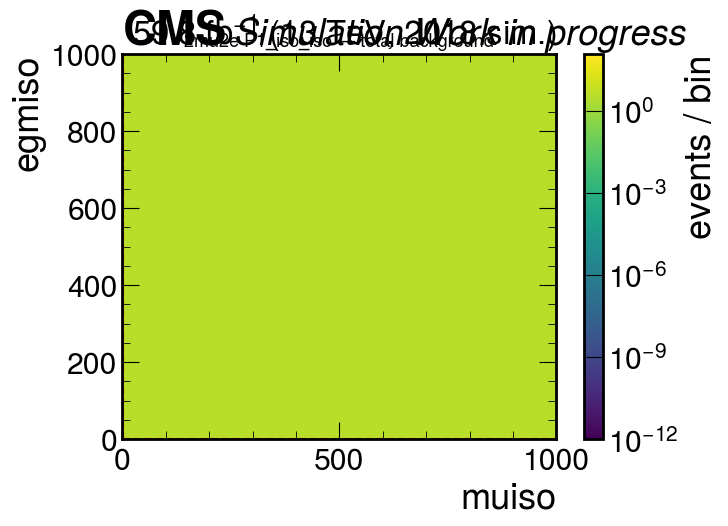

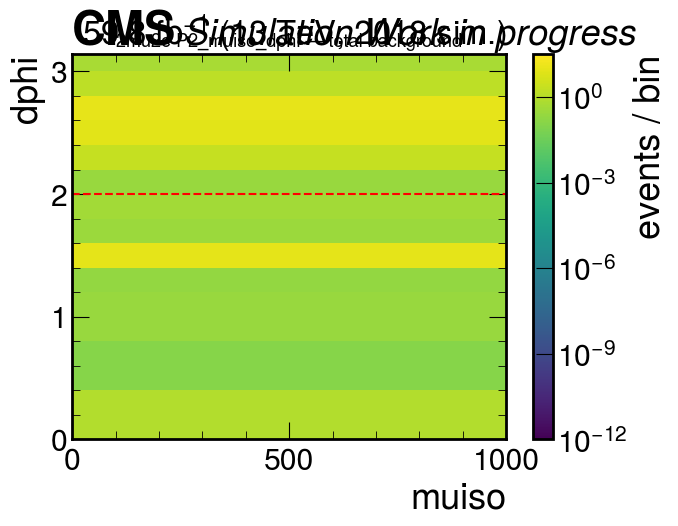

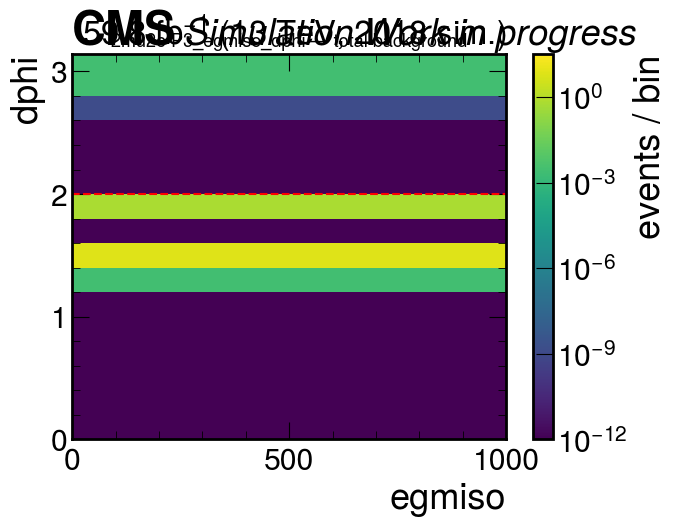

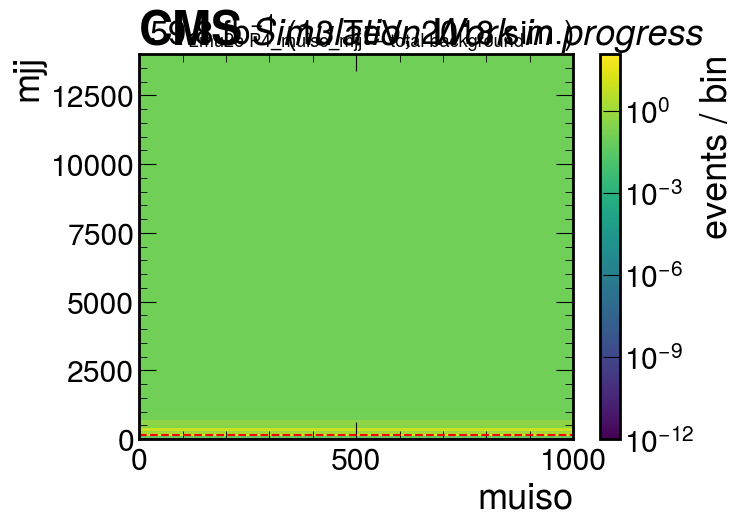

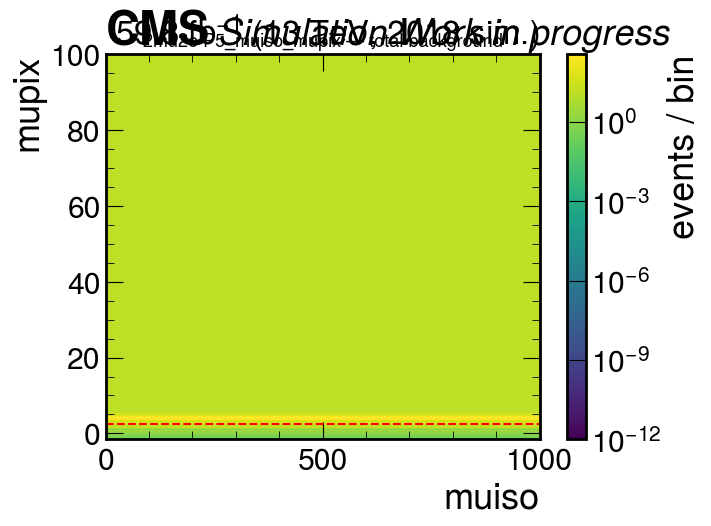

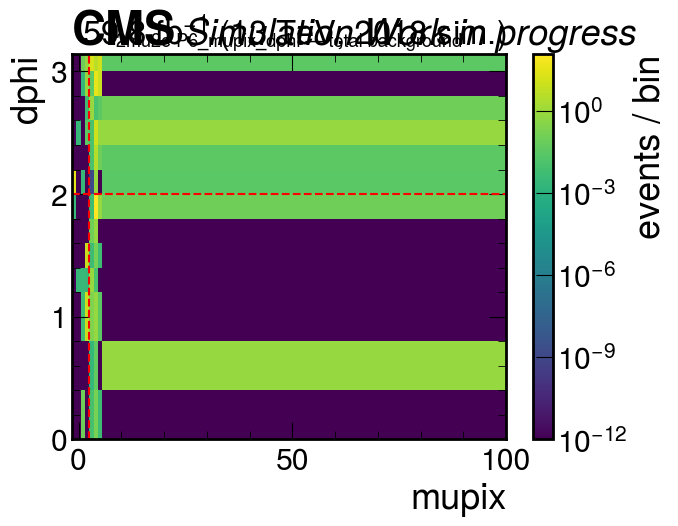

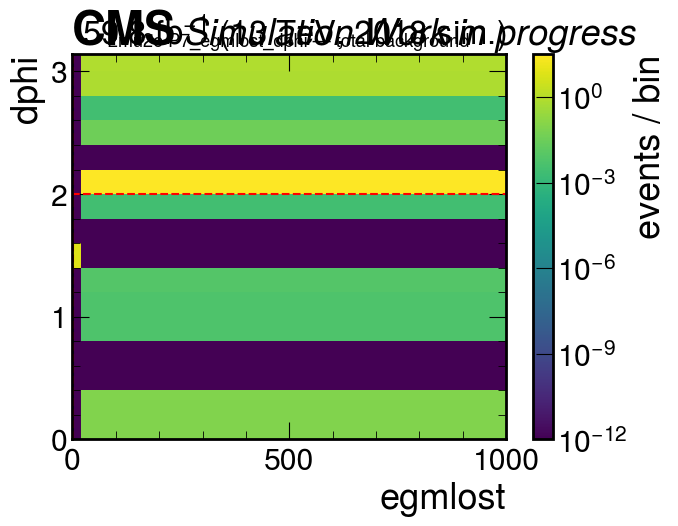

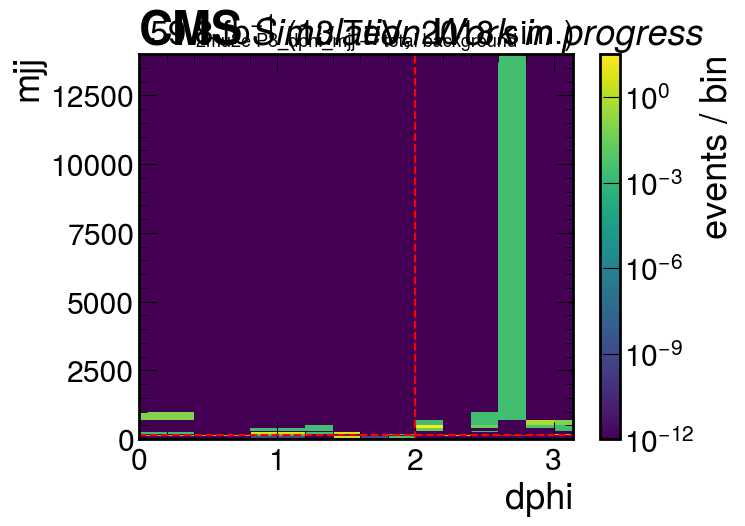

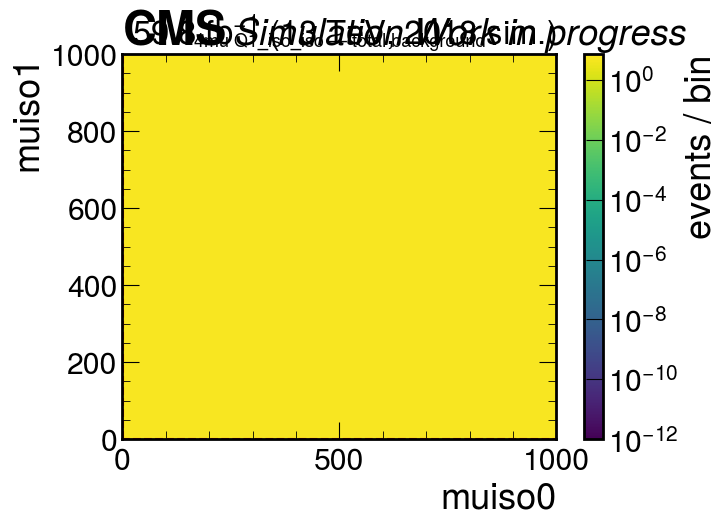

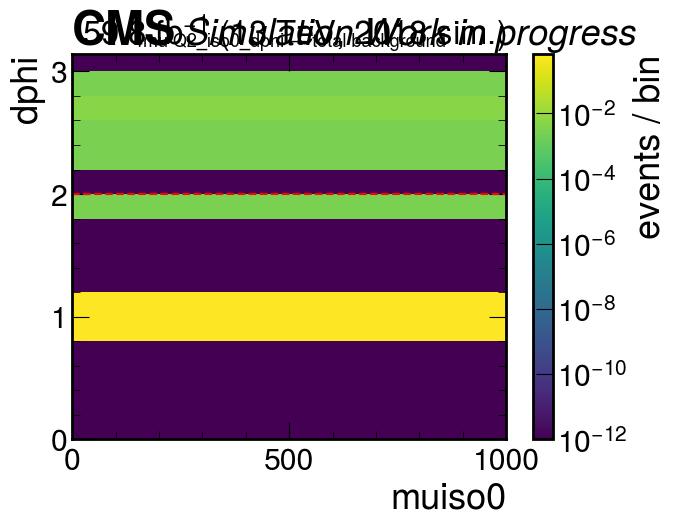

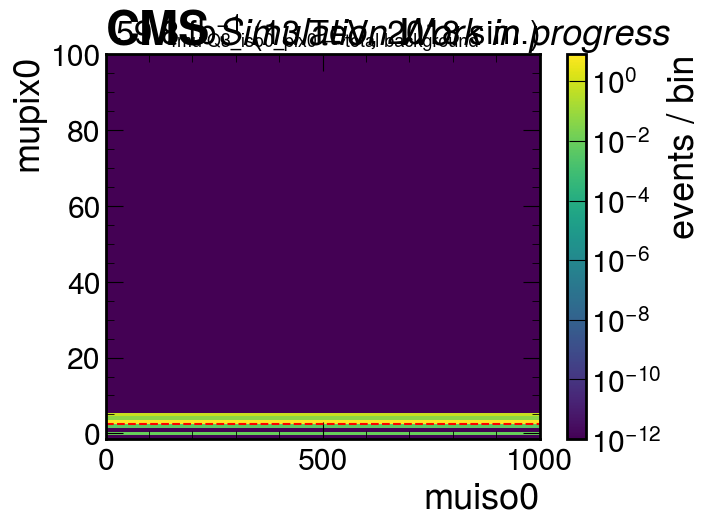

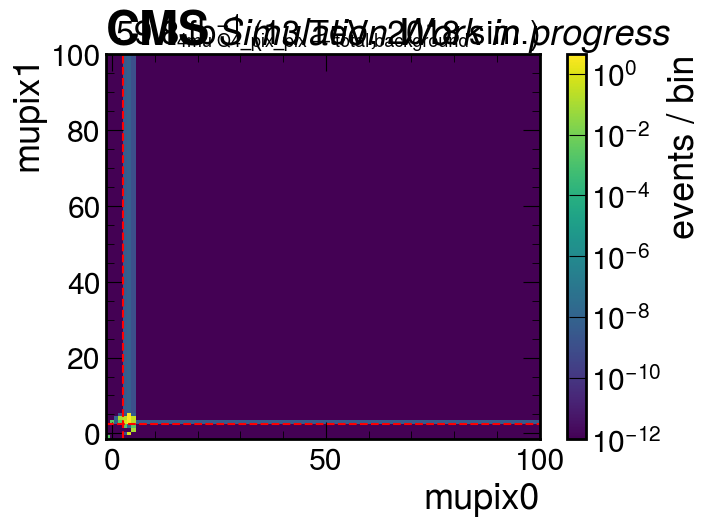

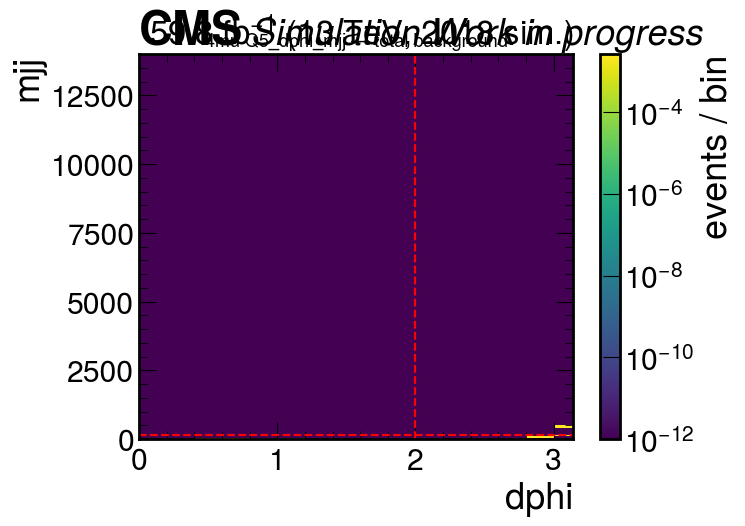

In [5]:
def plot_plane(vals, xe, ye, title, xcut=None, ycut=None, xlabel="", ylabel=""):
    fig, ax = plt.subplots()
    m = ax.pcolormesh(xe, ye, vals.T + 1e-12, norm="log", cmap="viridis")
    fig.colorbar(m, ax=ax, label="events / bin")
    if xcut is not None: ax.axvline(xcut, color="red", ls="--", lw=1.5)
    if ycut is not None: ax.axhline(ycut, color="red", ls="--", lw=1.5)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=13)
    cms_label(ax)
    plt.show()

for ch in ss.PLANES:
    for pname, spec in ss.PLANES[ch].items():
        vals, var, xe, ye = ss.plane_arrays(total_bkg, ch, pname, parity=0)
        plot_plane(vals, xe, ye, f"{ch} {pname} — total background",
                   xcut=spec["xspec"][1], ycut=spec["yspec"][1],
                   xlabel=spec["x"], ylabel=spec["y"])

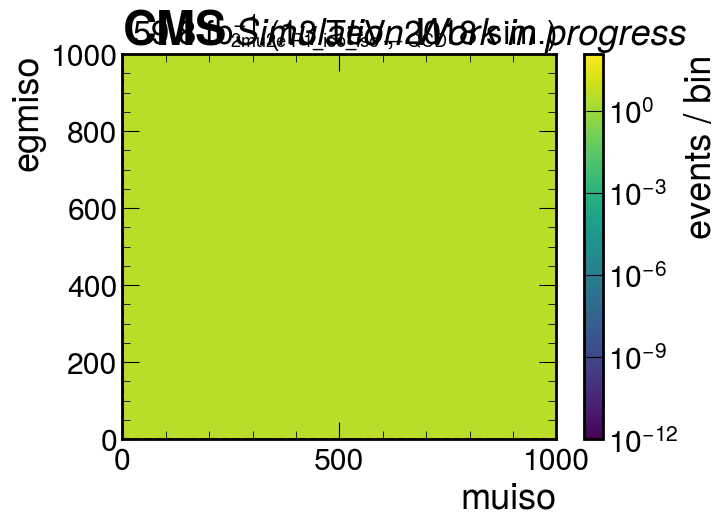

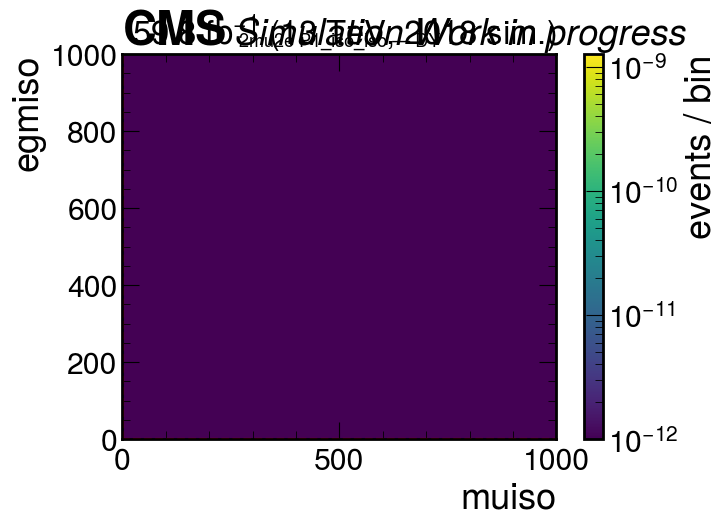

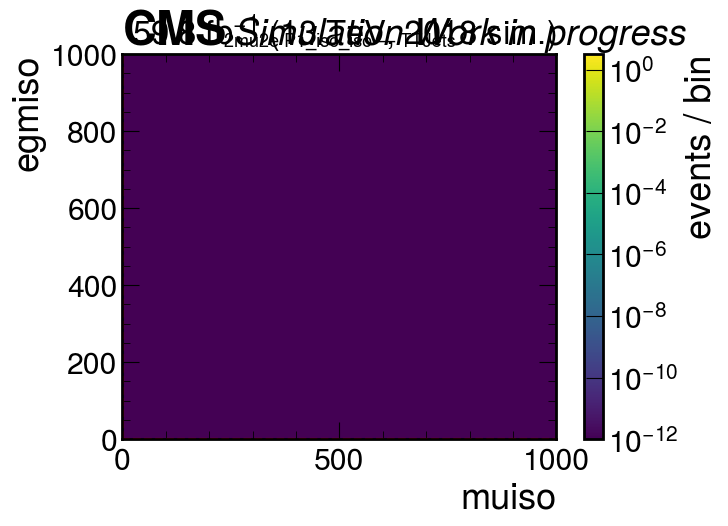

2mu2e P1_iso_iso Diboson: empty after SR cuts


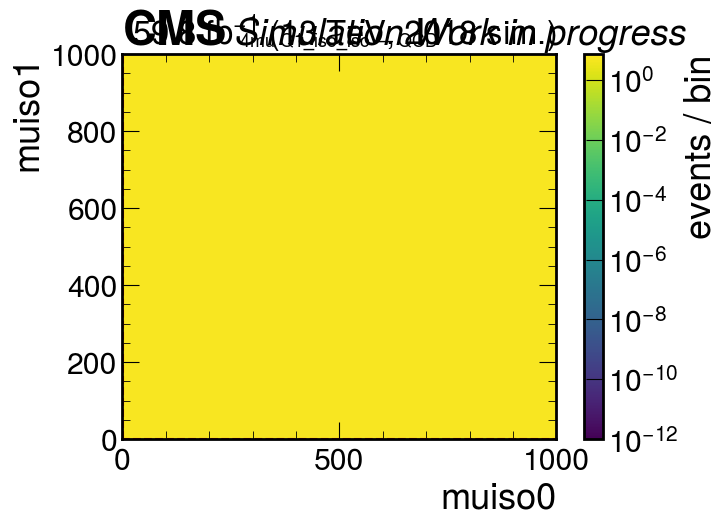

4mu Q1_iso_iso DY: empty after SR cuts


4mu Q1_iso_iso TTJets: empty after SR cuts


4mu Q1_iso_iso Diboson: empty after SR cuts


In [6]:
# per-process versions for the incumbent planes (the ones most likely chosen)
for ch, pname in [("2mu2e", "P1_iso_iso"), ("4mu", "Q1_iso_iso")]:
    for p in ss.PROCESSES:
        vals, var, xe, ye = ss.plane_arrays(by_process[p], ch, pname, parity=0)
        if vals.sum() <= 0:
            print(f"{ch} {pname} {p}: empty after SR cuts"); continue
        spec = ss.PLANES[ch][pname]
        plot_plane(vals, xe, ye, f"{ch} {pname} — {p}",
                   xcut=spec["xspec"][1], ycut=spec["yspec"][1],
                   xlabel=spec["x"], ylabel=spec["y"])

## Weighted correlations (descriptive)

Global weighted Pearson correlation of the two plane variables, per process. Not the
gate (that is the factorization fit in 02), but a first look: |r| well above ~0.1 is
an early warning.

In [7]:
print(f"{'plane':22s} " + " ".join(f"{p:>9s}" for p in ss.PROCESSES) + f" {'total':>9s}")
for ch in ss.PLANES:
    for pname in ss.PLANES[ch]:
        cells = []
        for hset in [by_process[p] for p in ss.PROCESSES] + [total_bkg]:
            vals, var, xe, ye = ss.plane_arrays(hset, ch, pname, parity=0)
            cells.append(at.weighted_correlation(vals, xe, ye))
        print(f"{ch+'/'+pname:22s} " + " ".join(f"{c:9.3f}" for c in cells))

plane                        QCD        DY    TTJets   Diboson     total


2mu2e/P1_iso_iso           0.033    -0.500       nan       nan     0.032


2mu2e/P2_muiso_dphi        0.177       nan       nan       nan     0.177


2mu2e/P3_egmiso_dphi      -0.224    -0.888       nan       nan    -0.221


2mu2e/P4_muiso_mjj         0.065       nan       nan       nan     0.065


...

2mu2e/P8_dphi_mjj          0.642     0.607       nan       nan     0.640


4mu/Q1_iso_iso             0.132       nan       nan       nan     0.132


4mu/Q2_iso0_dphi          -0.820       nan       nan       nan    -0.820


4mu/Q3_iso0_pix0           0.152     0.177       nan       nan     0.152
4mu/Q4_pix_pix            -0.310    -0.028       nan    -0.009     0.048


4mu/Q5_dphi_mjj            0.533     1.000       nan       nan     0.533


## Displacement-convention check

The scan axes use PF-muon pixel hits with explicit no-pixel-info (−1) and, on the egm
side, photon-only (999-fill) categories. This section shows where events actually sit,
so the offline displacement choice (N=2 vs N=3, photon-only handling) is made with
open eyes — including the ~63% photon-only fraction of signal 2mu2e events found in
the smoke test.

In [8]:
for label, hists in [("total bkg", total_bkg)] + [(s, load_sig(s)) for s in ss.SIGNALS_2MU2E[:3]]:
    h = at.get_channel(hists["abcd_scan_2mu2e_iso_iso"], ss.CHANNELS["2mu2e"])
    md = h.project("mudisp"); ed = h.project("egmdisp")
    mt, et = md.sum(flow=True).value, ed.sum(flow=True).value
    if mt <= 0: continue
    print(f"{label:28s} mudisp[noPix/<=2/==3/>=4]: "
          + "/".join(f"{md[i].value/mt:.3f}" for i in range(4))
          + f"   egmdisp[0lost/>=1/photon-only]: "
          + "/".join(f"{ed[i].value/et:.3f}" for i in range(3)))

total bkg                    mudisp[noPix/<=2/==3/>=4]: 0.017/0.084/0.191/0.707   egmdisp[0lost/>=1/photon-only]: 0.569/0.065/0.367
2Mu2E_100GeV_1p2GeV_0p096mm  mudisp[noPix/<=2/==3/>=4]: 0.000/0.037/0.181/0.782   egmdisp[0lost/>=1/photon-only]: 0.964/0.020/0.016


2Mu2E_100GeV_1p2GeV_9p6mm    mudisp[noPix/<=2/==3/>=4]: 0.163/0.673/0.075/0.088   egmdisp[0lost/>=1/photon-only]: 0.106/0.196/0.698
2Mu2E_100GeV_1p2GeV_96p0mm   mudisp[noPix/<=2/==3/>=4]: 0.586/0.362/0.026/0.026   egmdisp[0lost/>=1/photon-only]: 0.023/0.084/0.893


## mJJ sculpting inputs

Normalized leading mu-LJ isolation shapes in mJJ slices (total background). How to
read it: if the shapes drift with mJJ, an mJJ cut sculpts the iso axes — the effect
Samuel's study saw as closure degrading at low mJJ. Notebook 02 quantifies it per
process; this is the picture.

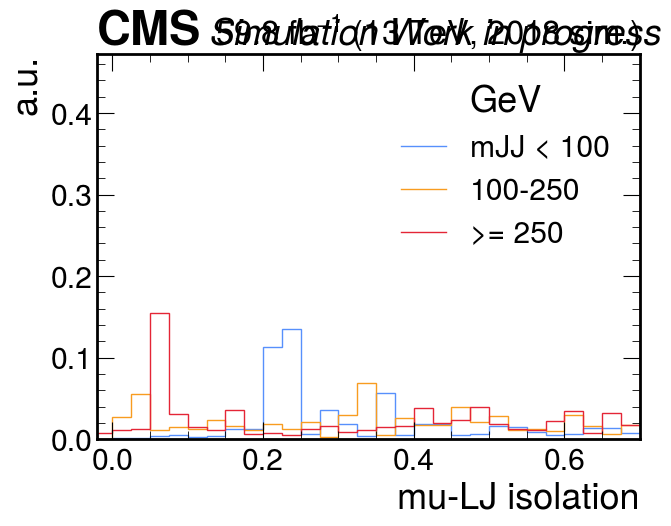

In [9]:
h = at.get_channel(total_bkg["abcd_scan_2mu2e_iso_iso"], ss.CHANNELS["2mu2e"])
fig, ax = plt.subplots()
for lo, hi, lab in [(0, 100, "mJJ < 100"), (100, 250, "100-250"), (250, 14000, ">= 250")]:
    vals, var, xe, ye = at.project_plane(h, "muiso", "egmiso",
        {"mjj": ("window", float(lo), float(hi)), "parity": ("bin", 0)})
    proj = vals.sum(axis=1)
    if proj.sum() > 0:
        ax.stairs(proj / proj.sum(), xe, label=lab)
ax.set_xlabel("mu-LJ isolation"); ax.set_ylabel("a.u."); ax.set_xlim(-0.02, 0.7)
ax.legend(title="GeV"); cms_label(ax)
plt.show()

## Findings

*(filled after execution)*